### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.82056822, 0.99242859, 0.63751816, 0.77412277, 0.03187126,
       0.7343555 , 0.32228826, 0.80895497, 0.87733668, 0.2638062 ,
       0.12435197, 0.09498237, 0.61002484, 0.65826032, 0.19536442,
       0.43125989, 0.9659824 , 0.32615719, 0.8639102 , 0.24824324])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 1e-02 #  for PD controller   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.84045486,  0.        ,  0.36945791],
        [ 0.        ,  1.        , -0.73153336],
        [-0.54188157,  0.        ,  0.57302687]],

       [[ 0.82359553,  0.        ,  0.31005209],
        [ 0.        ,  1.        , -0.83735605],
        [-0.56717758,  0.        ,  0.45022499]],

       [[ 0.68271018,  0.        ,  0.58716395],
        [ 0.        ,  1.        , -0.59520293],
        [-0.73068927,  0.        ,  0.54860912]],

       [[ 0.87385998,  0.        ,  0.34763385],
        [ 0.        ,  1.        , -0.69908909],
        [-0.48617767,  0.        ,  0.6248401 ]],

       [[ 0.56580062,  0.        ,  0.82412335],
        [ 0.        ,  1.        , -0.03186586],
        [-0.82454209,  0.        ,  0.56551328]],

       [[ 0.95908701,  0.        ,  0.21014313],
        [ 0.        ,  1.        , -0.6701089 ],
        [-0.28311149,  0.        ,  0.7118946 ]],

       [[ 0.76086277,  0.        ,  0.61550232],
        [ 0.        ,  1.        , -0.31673784],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.01357686,  0.        ,  0.01246941],
        [ 0.        ,  0.        , -0.00324697],
        [-0.02105763,  0.        , -0.01218475]],

       [[-0.13477772,  0.        , -0.1856533 ],
        [ 0.        ,  0.        , -0.33683689],
        [-0.19571   ,  0.        , -0.49861786]],

       [[-0.36573808,  0.        ,  0.06997588],
        [ 0.        ,  0.        , -0.37808165],
        [-0.3417227 ,  0.        , -0.48508603]],

       [[-0.36661279,  0.        ,  0.29481447],
        [ 0.        ,  0.        , -0.37102135],
        [-0.65895301,  0.        , -0.57913131]],

       [[-0.13649013,  0.        ,  0.07053882],
        [ 0.        ,  0.        , -0.87770193],
        [-0.0936595 ,  0.        , -0.15225358]],

       [[-0.144687  ,  0.        ,  0.18808647],
        [ 0.        ,  0.        , -0.68756193],
        [-0.49015115,  0.        , -0.70272544]],

       [[-0.55158734,  0.        ,  0.46230024],
        [ 0.        ,  0.        , -0.69752248],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.28912045, -0.53948365,  0.4396355 ],
       [ 0.61436582, -0.05104007, -0.19427074],
       [ 0.37051871,  0.45055935, -0.29772214],
       [ 0.48434304,  0.69191298, -0.19671385],
       [ 0.67349125,  0.15870464, -0.60286326],
       [ 0.96244458,  0.27496858, -0.01143423],
       [ 0.98091703,  0.6331702 ,  0.01688683],
       [ 0.61714913,  0.23298961,  0.36747469],
       [ 0.45490444,  0.57615858,  0.02396873],
       [ 0.25919406,  0.2878741 ,  0.0713156 ],
       [ 0.40733021,  0.02788009,  0.22385528],
       [ 1.05670017,  0.66431086,  0.36772717],
       [ 0.93543993,  0.09116097, -0.40089504],
       [ 1.10156941,  0.13057058,  0.09793396],
       [ 0.82579143,  0.6719651 , -0.08499459],
       [ 0.53871315,  0.882046  , -0.24687294],
       [ 0.45639244,  0.36369423, -0.13735228],
       [ 0.67072774,  0.61606828,  0.22726739],
       [ 1.00783533,  0.14860149, -0.24416849],
       [ 0.55110981,  0.43650936,  0.06822737]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 6.77825036e-01, -2.50703670e-01,  2.26519390e-01],
       [ 5.20966408e-01,  2.10636034e-01, -2.21339631e-01],
       [ 1.88312826e-01, -1.80427621e-01, -5.76700979e-02],
       [ 8.32050680e-01, -7.15526291e-01, -1.44175749e-01],
       [ 3.35691081e-01,  3.23774181e-01, -4.78335916e-01],
       [ 6.63747933e-01, -7.28238567e-01, -2.41128370e-01],
       [ 1.03666727e+00, -4.34482771e-02, -8.43246447e-01],
       [ 6.38088664e-01, -7.42843731e-01, -1.53088204e-01],
       [ 7.16918619e-01, -5.34839779e-03, -1.14674185e+00],
       [ 8.33395154e-01,  9.13207054e-01, -4.32907302e-01],
       [ 1.51732994e-01,  1.43177943e-01,  4.01644688e-01],
       [ 6.43055040e-01,  3.43085799e-02, -2.87829883e-01],
       [-3.43873425e-01, -2.20238222e-01, -6.79322516e-01],
       [ 2.63665673e-01, -3.68678144e-01, -1.00827134e+00],
       [ 4.61370462e-01,  9.69918256e-02, -8.74657398e-01],
       [-5.43496071e-02,  6.50598510e-04, -4.45831869e-01],
       [ 5.36377452e-01, -2.64728188e-03

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.23705715, 0.80315205, 0.95411992],
       [0.08357317, 0.31739721, 0.29377372],
       [0.05702011, 0.55428276, 0.63434243],
       [0.84041608, 0.97418532, 0.29000865],
       [0.06697508, 0.2695214 , 0.76932424],
       [0.58969227, 0.12377225, 0.87455285],
       [0.96328517, 0.0598976 , 0.90162777],
       [0.79378023, 0.08292698, 0.00718079],
       [0.93765084, 0.7512345 , 0.50415725],
       [0.9310485 , 0.2342425 , 0.05298318],
       [0.36171039, 0.94660726, 0.86131891],
       [0.92467935, 0.98978995, 0.56460008],
       [0.21455107, 0.45047816, 0.91871509],
       [0.03924322, 0.53268385, 0.9592053 ],
       [0.93248158, 0.51246529, 0.15881958],
       [0.21166964, 0.58309191, 0.55375192],
       [0.52018077, 0.88025584, 0.26102534],
       [0.49775744, 0.62113439, 0.08300722],
       [0.66836263, 0.67924948, 0.07549939],
       [0.93106935, 0.54988716, 0.76037498]])

In [44]:
theta(φ,θ,ψ)

array([[0.82056822, 0.57267425, 0.74655124],
       [0.99242859, 0.60307484, 0.22662392],
       [0.63751816, 0.81933102, 0.13033336],
       [0.77412277, 0.50771033, 0.67893934],
       [0.03187126, 0.96939241, 0.36495798],
       [0.7343555 , 0.28703678, 0.16170079],
       [0.32228826, 0.70615468, 0.97476277],
       [0.80895497, 0.2313461 , 0.51198429],
       [0.87733668, 0.76884778, 0.83501376],
       [0.2638062 , 0.43273337, 0.94313327],
       [0.12435197, 0.06768647, 0.56417846],
       [0.09498237, 0.59800332, 0.876205  ],
       [0.61002484, 0.92281494, 0.20980962],
       [0.65826032, 0.67541631, 0.92589583],
       [0.19536442, 0.78485587, 0.04513799],
       [0.43125989, 0.81431347, 0.31135283],
       [0.9659824 , 0.42191891, 0.18639389],
       [0.32615719, 0.69094259, 0.36455605],
       [0.8639102 , 0.83530375, 0.60223443],
       [0.24824324, 0.41089945, 0.51804196]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.83195796,  0.57908356,  0.47347671],
       [ 0.17076403,  0.29287417,  0.25204313],
       [ 0.38181606,  0.51813207,  0.50847933],
       [ 0.63223656,  0.75815185, -0.58652423],
       [ 0.26894598,  0.21803436,  0.72205442],
       [ 0.6749156 , -0.36257121,  0.64848949],
       [ 0.99236689, -0.68040305,  0.45608537],
       [ 0.79146947,  0.07780701, -0.06073283],
       [ 0.88888231,  0.34479787, -0.4219729 ],
       [ 0.91296364,  0.19173693, -0.18533538],
       [ 0.86507995,  0.64180848,  0.17731063],
       [ 0.79168439,  0.53899758, -0.58636782],
       [ 0.58398087,  0.25487563,  0.71468564],
       [ 0.5205606 ,  0.4950512 ,  0.80573897],
       [ 0.85909388,  0.38491712, -0.37474621],
       [ 0.47478934,  0.46675274,  0.3353886 ],
       [ 0.50593996,  0.75051659, -0.25673868],
       [ 0.44723068,  0.58150206, -0.23036203],
       [ 0.5572402 ,  0.63246237, -0.37376877],
       [ 1.03103199, -0.06013035, -0.09955872]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.88612629, -0.27978751,  0.36945791],
        [ 0.46302191,  0.50046943, -0.73153336],
        [ 0.01977151,  0.81929805,  0.57302687]],

       [[ 0.9092481 ,  0.27773297,  0.31005209],
        [ 0.12282804,  0.53268012, -0.83735605],
        [-0.39771997,  0.79944749,  0.45022499]],

       [[ 0.73344259,  0.34249157,  0.58716395],
        [ 0.10443643,  0.79676   , -0.59520293],
        [-0.67168073,  0.49786848,  0.54860912]],

       [[ 0.8935068 , -0.28424693,  0.34763385],
        [ 0.44901878,  0.55646795, -0.69908909],
        [ 0.00526683,  0.78073498,  0.6248401 ]],

       [[ 0.53791401, -0.17739567,  0.82412335],
        [ 0.35672879,  0.93366436, -0.03186586],
        [-0.76380173,  0.31112962,  0.56551328]],

       [[ 0.97711925,  0.0328305 ,  0.21014313],
        [ 0.11950212,  0.73257989, -0.6701089 ],
        [-0.17594664,  0.67988886,  0.7118946 ]],

       [[ 0.59721581, -0.51428608,  0.61550232],
        [ 0.78495981,  0.53246149, -0.31673784],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 0.03886777, -0.92517002,  0.76912587],
       [ 0.26769257, -0.29927571,  0.24718806],
       [ 0.68909533, -0.34712013,  0.2413687 ],
       [-0.03704069, -0.22440362,  0.86114777],
       [ 0.68828673, -0.23320016,  0.02177804],
       [ 0.16774969, -0.70039248, -0.01398605],
       [ 0.32870662, -0.28585467, -0.33219497],
       [-0.01414292,  0.11957892,  0.18243811],
       [ 0.23395977, -0.71729321,  0.6336968 ],
       [-0.15780822,  0.63366432, -0.02838642],
       [-0.5227287 ,  0.05951364,  0.1541129 ],
       [-0.36988173,  0.29556006,  0.08763659],
       [ 0.9097206 , -0.54631664,  0.05542762],
       [ 0.01929422, -0.9257523 ,  0.51331673],
       [ 0.17796009, -0.12645614, -0.63682407],
       [ 0.448536  , -0.30311373,  0.14772266],
       [ 0.33320875, -0.39684   ,  0.6742332 ],
       [ 0.01145521, -0.01012008,  0.0070357 ],
       [ 0.28535515, -0.31840623,  0.33850003],
       [ 0.01703188,  0.01074525, -0.02862605]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 0.02947228, -0.7346049 ,  0.53111598],
       [ 0.37159386, -0.65851925,  0.1251237 ],
       [ 0.41975879, -0.31809008, -0.05357633],
       [-0.00184936, -0.58247507,  0.43768305],
       [ 0.17494647, -0.11060945,  0.27852027],
       [ 0.05552694, -0.18752352,  0.08070233],
       [ 0.03830185, -0.66453642,  0.46875125],
       [-0.10788993, -0.31640419,  0.31344119],
       [ 0.27986365, -1.03504563,  0.65898062],
       [-0.13363329, -0.39710917,  0.21958262],
       [-0.03852805, -0.0229481 ,  0.01124523],
       [ 0.05204774, -0.43567078,  0.29169995],
       [ 0.52144702, -0.33940145, -0.02331118],
       [-0.00718381, -0.79430092,  0.58452862],
       [ 0.1188079 , -0.02850488, -0.01857886],
       [ 0.31032642, -0.20774226,  0.11349177],
       [ 0.176171  , -0.46107616,  0.13068382],
       [ 0.16903408, -0.15285006,  0.13846688],
       [ 0.5431434 , -0.85043862,  0.40042122],
       [-0.00149442, -0.13213815,  0.10552518]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 3.88677661e+07, -9.25170021e+08,  7.69125867e+08],
       [ 2.67692571e+08, -2.99275714e+08,  2.47188064e+08],
       [ 6.89095330e+08, -3.47120131e+08,  2.41368702e+08],
       [-3.70406936e+07, -2.24403618e+08,  8.61147770e+08],
       [ 6.88286728e+08, -2.33200165e+08,  2.17780440e+07],
       [ 1.67749688e+08, -7.00392481e+08, -1.39860492e+07],
       [ 3.28706622e+08, -2.85854672e+08, -3.32194965e+08],
       [-1.41429174e+07,  1.19578919e+08,  1.82438107e+08],
       [ 2.33959770e+08, -7.17293212e+08,  6.33696801e+08],
       [-1.57808224e+08,  6.33664319e+08, -2.83864161e+07],
       [-5.22728703e+08,  5.95136441e+07,  1.54112901e+08],
       [-3.69881734e+08,  2.95560059e+08,  8.76365905e+07],
       [ 9.09720603e+08, -5.46316638e+08,  5.54276182e+07],
       [ 1.92942180e+07, -9.25752304e+08,  5.13316733e+08],
       [ 1.77960093e+08, -1.26456135e+08, -6.36824072e+08],
       [ 4.48536003e+08, -3.03113733e+08,  1.47722663e+08],
       [ 3.33208746e+08, -3.96840004e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 4.82259106e+06, -7.43222992e+08, -8.94255549e+08],
       [-3.57563780e+07, -3.42776818e+08, -3.76284594e+08],
       [ 4.21583785e+07, -3.95252520e+08, -6.88785442e+08],
       [ 3.92208274e+07, -7.87567969e+08, -2.03542692e+08],
       [ 6.28597378e+07,  1.17023994e+08, -7.33560311e+08],
       [-6.74888310e+07, -5.23981107e+06, -5.47067006e+08],
       [ 9.29106332e+06,  4.43258646e+08, -3.72231773e+08],
       [-4.43320592e+07, -1.60677049e+08,  1.01878952e+08],
       [-8.21209533e+07, -6.87724819e+08, -7.48129617e+08],
       [-4.58974204e+08, -9.53458265e+07,  4.23183250e+08],
       [-3.30930678e+07, -3.12524130e+08,  8.44026301e+06],
       [-1.52135596e+08, -2.96778641e+08,  3.58796871e+08],
       [-1.64522401e+08, -3.76048513e+08, -1.00621572e+09],
       [ 2.04139567e+08, -4.95687623e+08, -9.01631766e+08],
       [-5.07733127e+08,  8.89533787e+07, -1.59549457e+08],
       [ 6.48443648e+07, -1.27712935e+08, -4.58944993e+08],
       [ 6.24805151e+07, -7.23037847e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 9654698.07029964,   265471.12325757,  -168568.79679055],
       [ 8876249.72304402,  4133099.27496246, -4608514.9014936 ],
       [ 5117671.8681546 ,  7417562.22619   , -3943256.12751592],
       [ 9124972.01832617,   330712.43476056,   478673.20153575],
       [ 3188031.69490733,  9577627.05511909,  1801093.90308106],
       [ 7382911.23597696,  1786796.43191189,  -927905.57410687],
       [ 8451858.86210149,  3974104.26259171,  4943379.27441249],
       [ 8684336.03671729, -1391084.43785573,  1585009.98420957],
       [10016676.15603225,  1266894.53303739, -2264118.10140219],
       [ 6213130.56438012,  1868048.10305409,  7159492.36420396],
       [ 1619306.64171119,   -22895.64157589,  5501295.86918051],
       [ 5695734.05108472,  5149043.72173622,  6674110.8536783 ],
       [ 5053076.74068773,  8026175.62859088, -3825795.63889419],
       [ 9716730.38972195,  1090073.30163054,  1600690.37874403],
       [ 1695116.27017527,  7760935.02789326, -1067413.79449937],
       [ 5

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[ 3.63797881e-11, -8.57585757e-10,  7.27595761e-10],
       [ 2.32830644e-10, -2.62959156e-10,  0.00000000e+00],
       [ 0.00000000e+00, -4.15349922e-10, -4.65661287e-10],
       [-3.27418093e-11,  4.86250326e-10,  2.91038305e-10],
       [ 2.32830644e-10, -4.76774919e-11,  0.00000000e+00],
       [ 5.82076609e-11,  1.63022063e-11,  4.65661287e-10],
       [-2.32830644e-10,  1.37269968e-10,  4.65661287e-10],
       [ 5.82076609e-11,  8.57636475e-10,  2.32830644e-10],
       [ 1.16415322e-10, -2.36128762e-10,  2.32830644e-10],
       [ 6.98491931e-10, -8.12600569e-10, -4.65661287e-10],
       [ 0.00000000e+00,  2.90571481e-11,  0.00000000e+00],
       [ 1.39698386e-09, -5.42700147e-10,  0.00000000e+00],
       [ 0.00000000e+00, -1.06482281e-10, -4.65661287e-10],
       [-1.16415322e-10,  3.46427857e-10,  4.65661287e-10],
       [ 1.16415322e-10, -4.07479321e-11,  0.00000000e+00],
       [ 0.00000000e+00,  7.07908259e-11,  9.31322575e-10],
       [-1.16415322e-10,  5.79557514e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[7.11335186e+01, 1.10944765e+02, 7.67045652e+01],
       [2.09738881e+02, 3.95496109e+02, 2.46778425e+02],
       [2.26522233e+02, 9.71598374e+01, 3.14457140e+01],
       [1.25642644e+02, 2.30246836e+02, 2.97147839e+02],
       [8.93904618e+01, 6.19373127e+00, 2.14268013e+00],
       [3.61522285e+02, 3.95299988e+02, 2.97620490e+02],
       [1.17539384e-01, 2.54399888e+02, 3.79437092e+02],
       [1.03078561e+02, 1.41819362e+02, 3.16781330e+02],
       [3.29214117e+02, 9.68491933e+00, 2.25149188e+00],
       [3.63466797e+01, 2.59285925e+02, 2.55196703e+02],
       [2.48987597e+00, 4.80559351e+01, 3.63141836e+01],
       [2.43494262e+02, 3.80889848e+01, 3.16780919e+02],
       [1.05696508e+02, 1.04753918e+02, 3.26933945e+02],
       [3.71253082e+02, 1.15834019e+02, 2.48619690e+02],
       [1.66241085e-01, 2.30346667e+02, 1.17486389e+02],
       [2.95847699e+02, 2.54834293e+02, 2.98992630e+02],
       [1.50774288e+02, 1.51743240e+02, 1.15118760e+02],
       [1.40483726e+01, 2.49679

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 28958.40758308],
       [ 5845.36330569,  5845.36330569, 12961.87444244],
       [ 5845.36330569,  5845.36330569, 21211.9689662 ],
       [ 5845.36330569,  5845.36330569, 12870.66762656],
       [ 5845.36330569,  5845.36330569, 24481.83104084],
       [ 5845.36330569,  5845.36330569, 27030.937873  ],
       [ 5845.36330569,  5845.36330569, 27686.81330707],
       [ 5845.36330569,  5845.36330569,  6019.31410278],
       [ 5845.36330569,  5845.36330569, 18058.30272072],
       [ 5845.36330569,  5845.36330569,  7128.85258704],
       [ 5845.36330569,  5845.36330569, 26710.35281763],
       [ 5845.36330569,  5845.36330569, 19522.49801901],
       [ 5845.36330569,  5845.36330569, 28100.74444282],
       [ 5845.36330569,  5845.36330569, 29081.59814698],
       [ 5845.36330569,  5845.36330569,  9692.6825141 ],
       [ 5845.36330569,  5845.36330569, 19259.70707999],
       [ 5845.36330569,  5845.36330569, 12168.56241033],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-7.11335186e+01, -1.10944765e+02, -3.51875717e+02],
       [-2.09738881e+02, -3.95496109e+02, -5.21949577e+02],
       [-2.26522233e+02, -9.71598374e+01, -3.06616866e+02],
       [-1.25642644e+02, -2.30246836e+02, -5.72318991e+02],
       [-8.93904618e+01, -6.19373127e+00, -2.77313832e+02],
       [-3.61522285e+02, -3.95299988e+02, -5.72791642e+02],
       [-1.17539384e-01, -2.54399888e+02, -6.54608244e+02],
       [-1.03078561e+02, -1.41819362e+02, -5.91952482e+02],
       [-3.29214117e+02, -9.68491933e+00, -2.77422644e+02],
       [-3.63466797e+01, -2.59285925e+02, -5.30367854e+02],
       [-2.48987597e+00, -4.80559351e+01, -3.11485335e+02],
       [-2.43494262e+02, -3.80889848e+01, -5.91952070e+02],
       [-1.05696508e+02, -1.04753918e+02, -6.02105097e+02],
       [-3.71253082e+02, -1.15834019e+02, -5.23790841e+02],
       [-1.66241085e-01, -2.30346667e+02, -3.92657541e+02],
       [-2.95847699e+02, -2.54834293e+02, -5.74163782e+02],
       [-1.50774288e+02, -1.51743240e+02

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[113.64991499, -27.02707901,  21.17093101],
        [-27.02707901, 153.51410615, -41.91882702],
        [ 21.17093101, -41.91882702, 132.83597886]],

       [[109.61322992, -25.96239958,  13.95931984],
        [-25.96239958, 170.11651627, -37.69986182],
        [ 13.95931984, -37.69986182, 120.27025381]],

       [[134.47615005, -34.9481703 ,  32.21234974],
        [-34.9481703 , 135.42665308, -32.65337582],
        [ 32.21234974, -32.65337582, 130.09719688]],

       [[112.08492902, -24.30270293,  21.72155665],
        [-24.30270293, 148.87255592, -43.68188984],
        [ 21.72155665, -43.68188984, 139.04251505]],

       [[167.9179294 ,  -2.62614019,  46.60527002],
        [ -2.62614019, 100.10154332,  -1.80205689],
        [ 46.60527002,  -1.80205689, 131.98052728]],

       [[104.41601335, -14.08187799,  14.95997572],
        [-14.08187799, 144.90459424, -47.70469109],
        [ 14.95997572, -47.70469109, 150.6793924 ]],

       [[137.88431031, -19.49528723,  44.42008374],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

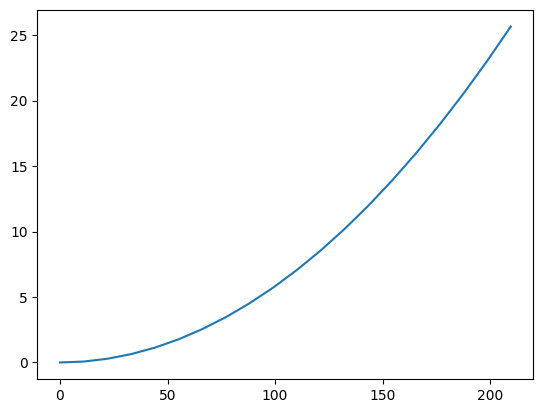

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

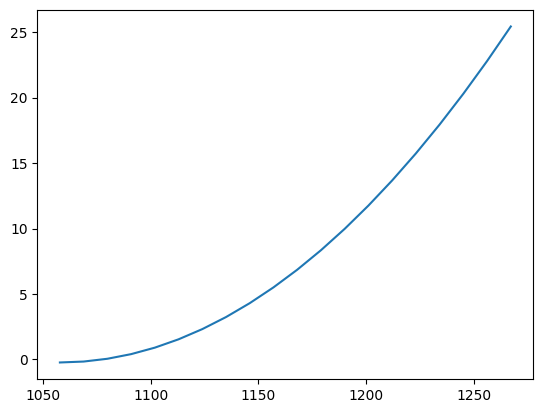

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

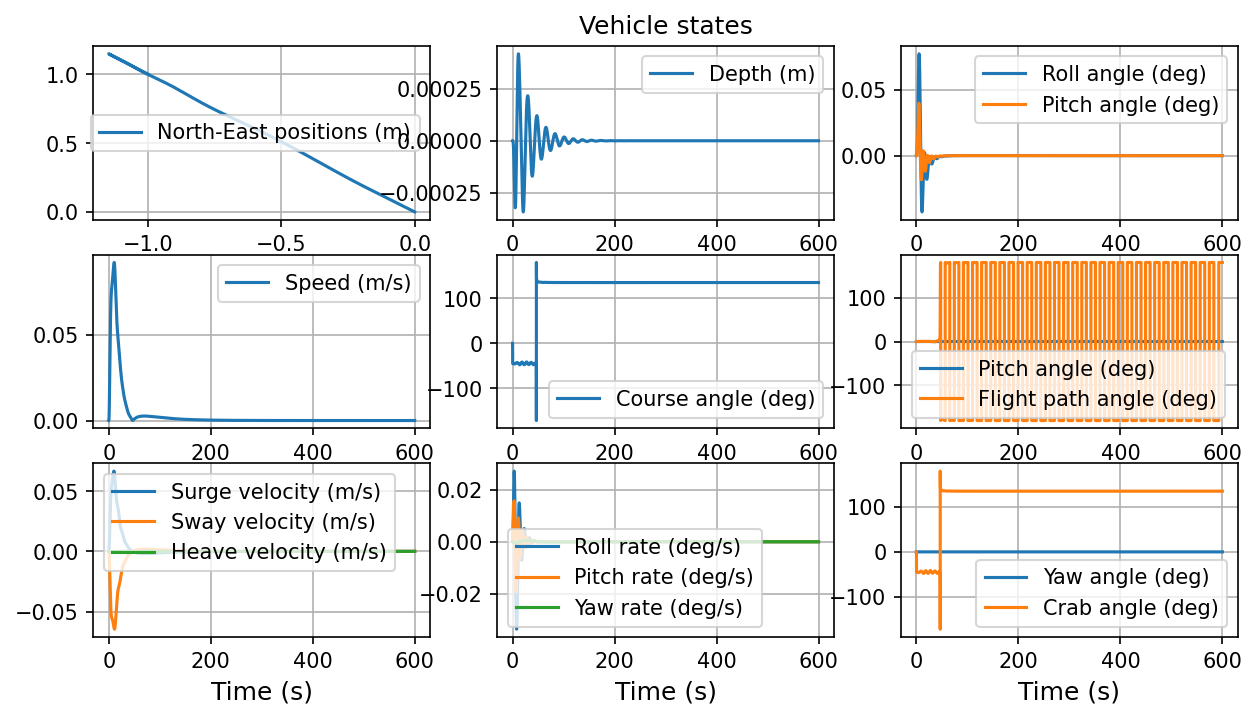

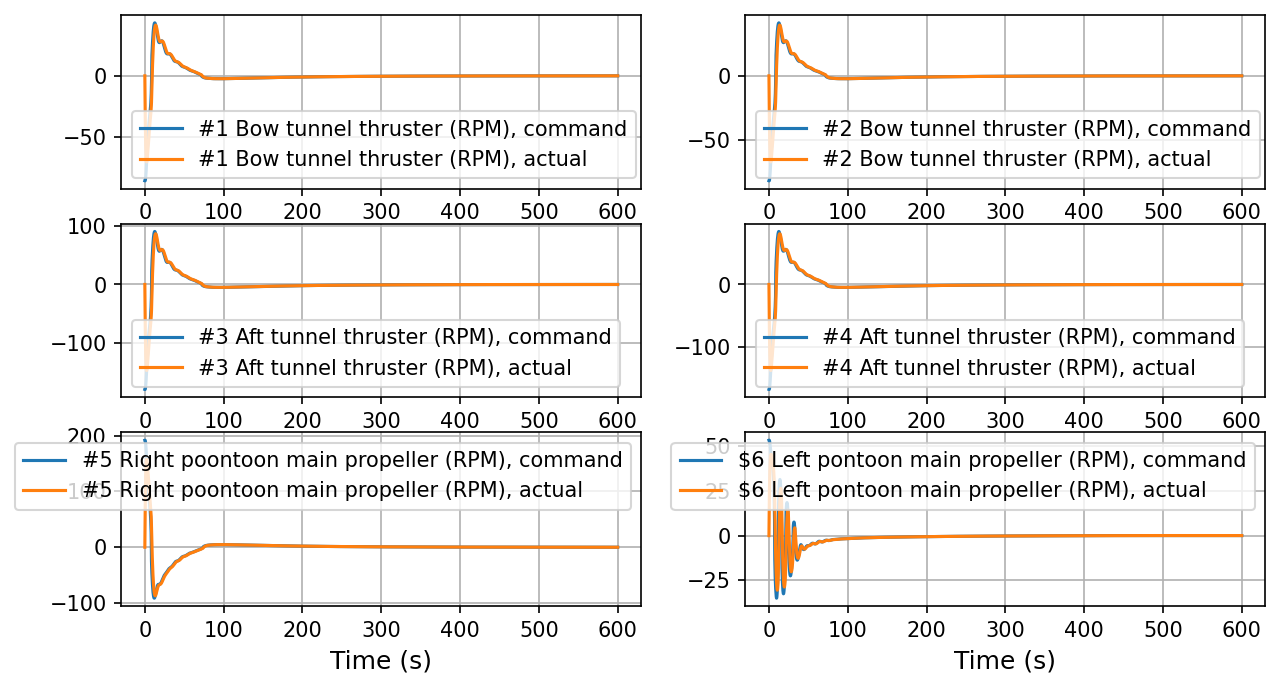

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

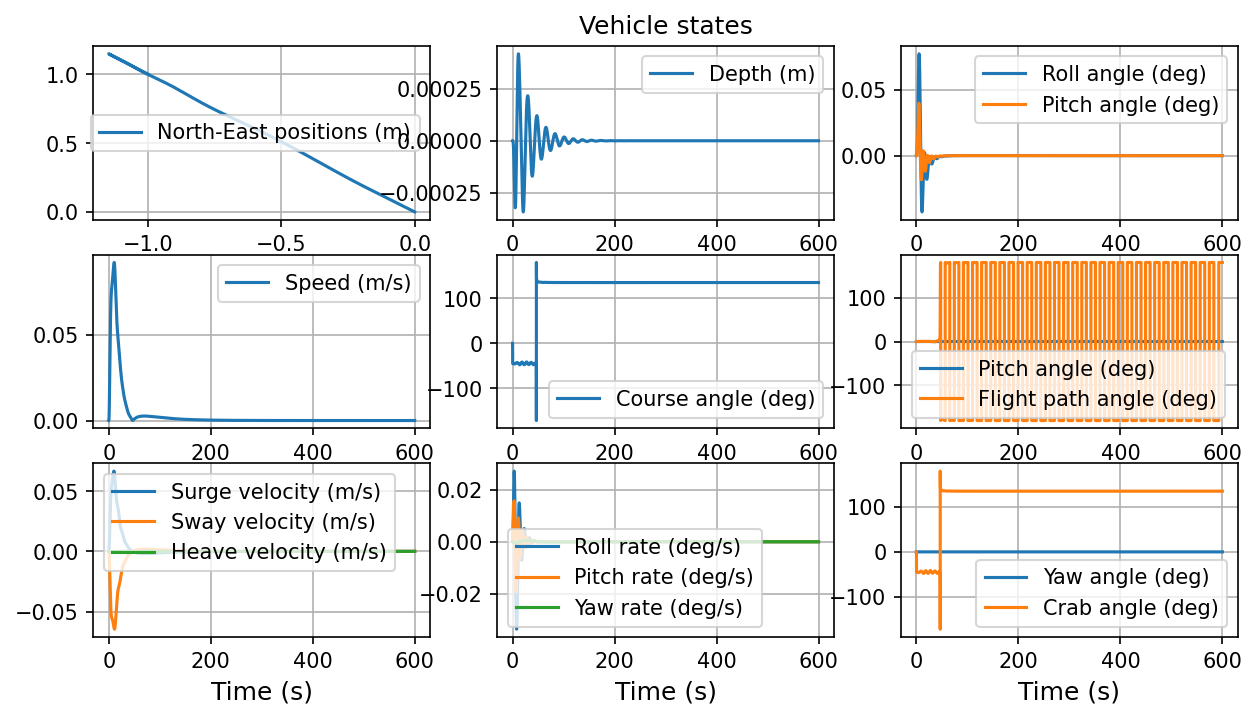

In [95]:
plotVehicleStates(simTime, simData, 3)

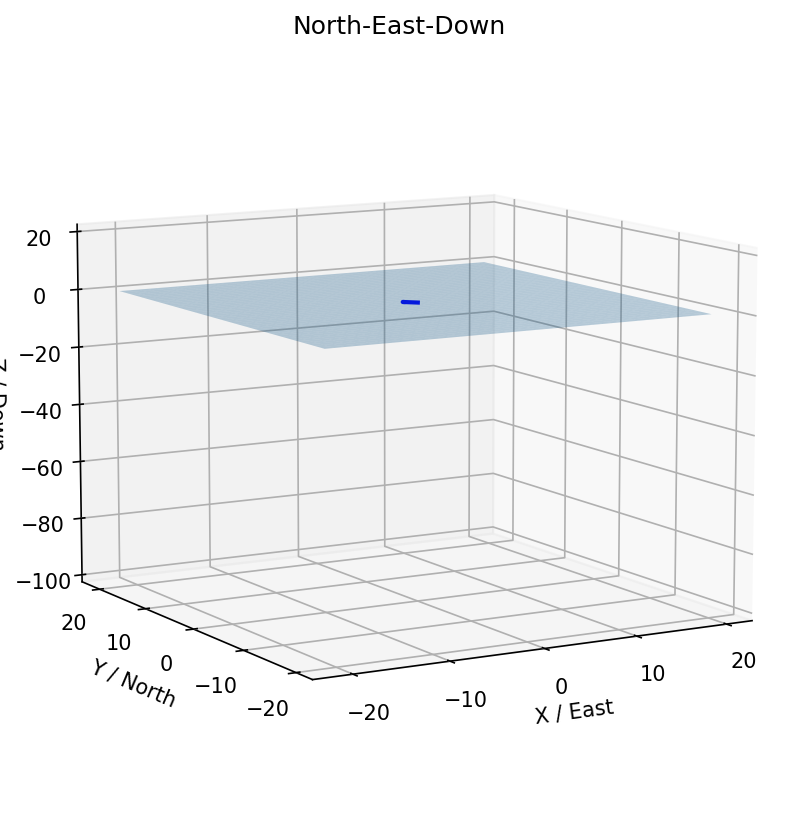

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    

    
    RET = Ret(φ,θ,ψ)
    
    s = np.linspace(0, 1, N)

    x_ref = np.array(x0) + s * x_ve 
    y_ref = np.zeros(N)  + s * y_ve
    z_ref = np.array(z0) + s * z_ve
    φ_ref = np.zeros(N)  + s * phi_ve
    θ_ref = np.zeros(N)  + s * theta_ve
    ψ_ref = np.zeros(N)  + s * psi_ve

    position_error  = np.sqrt((x - x_ref)**2 + (y - y_ref)**2 + (z - z_ref)**2)
    position_ang_error = np.sqrt((φ - φ_ref)**2 + (θ - θ_ref)**2 + (ψ - ψ_ref)**2)

    velocity_error  = np.sqrt(dx**2 + dy**2 + dz**2)
    velocity_ang_error = np.sqrt(dφ**2 + dθ**2 + dψ**2)     
    
    Z0 = calibr*(np.tile(position_error, (3, 1)) + np.tile(velocity_error, (3, 1))).T
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T
    Z = (Z1 + Z2 - Z0 )

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = calibr*(np.tile(position_ang_error, (3, 1)) + np.tile(velocity_ang_error, (3, 1))).T
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = (C1 - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001267*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.304741346215793e-08  Iteration wall-clock time:  0:00:00.015260
Physical time:  1.0123080590691669  Iteration wall-clock time:  0:00:00.819507
Physical time:  2.0032647405624857  Iteration wall-clock time:  0:00:01.006685
Physical time:  3.000485322741021  Iteration wall-clock time:  0:00:00.963388
Physical time:  4.008753432268869  Iteration wall-clock time:  0:00:00.971528
Physical time:  5.019811397653957  Iteration wall-clock time:  0:00:01.010236
Physical time:  6.025418308629058  Iteration wall-clock time:  0:00:01.067218
Physical time:  7.001063396678499  Iteration wall-clock time:  0:00:01.239285
Physical time:  8.002095714106458  Iteration wall-clock time:  0:00:01.197716
Physical time:  9.000265868268881  Iteration wall-clock time:  0:00:01.130691
0:00:10.643519


In [102]:
# max axial tension
T_.top_tension

320635.5022587152

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.0001251886569939797

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.305e-06 ...  9.968e+00  1.000e+01]
        y: [[ 0.000e+00 -1.143e-20 ...  3.229e-02  3.268e-02]
            [ 1.103e+01  1.103e+01 ...  1.068e+01  1.068e+01]
            ...
            [ 0.000e+00 -4.730e-12 ... -4.637e-06 -4.653e-06]
            [ 0.000e+00 -4.734e-12 ... -4.629e-06 -4.644e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1886
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((223,), (223, 240))

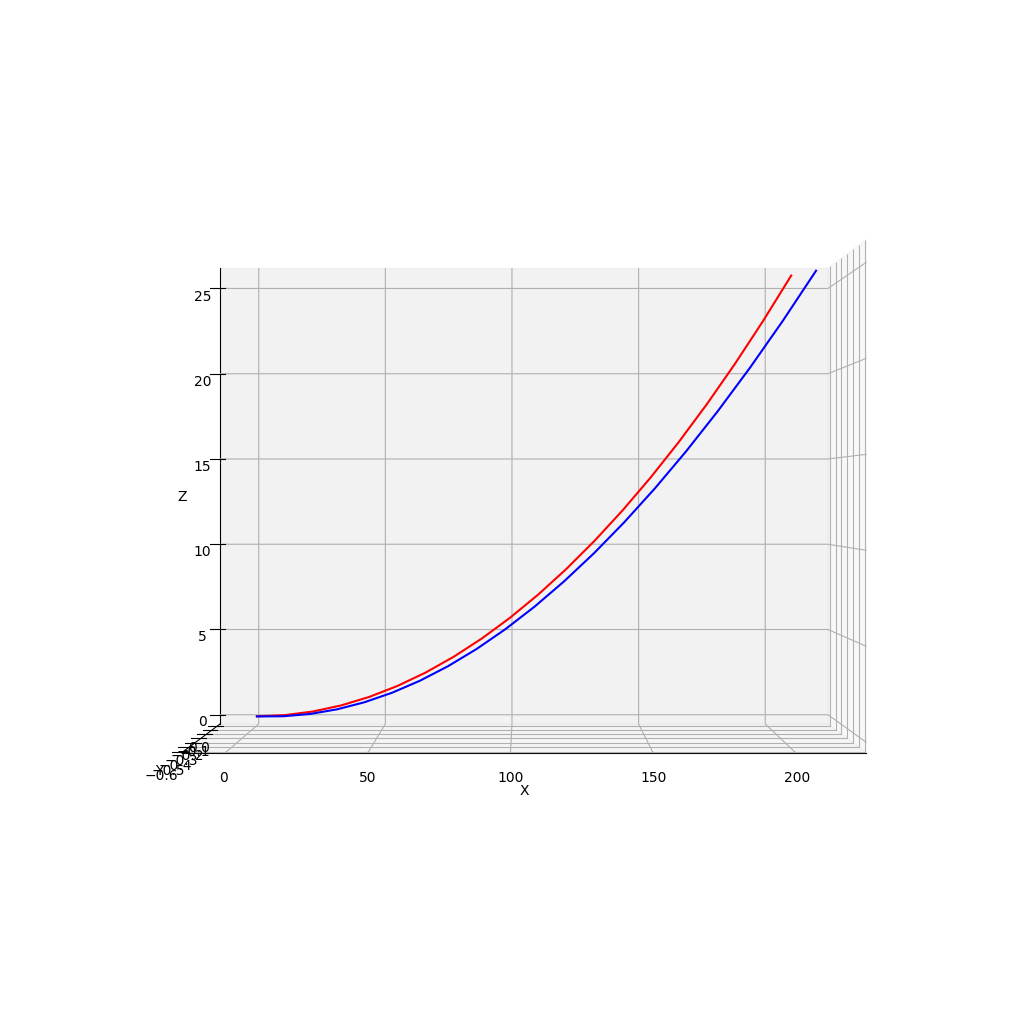

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([3.26812199e-02, 1.06754853e+01, 2.14383456e+01, 3.22564395e+01,
        4.31082702e+01, 5.39844905e+01, 6.48805372e+01, 7.57942456e+01,
        8.67247483e+01, 9.76720873e+01, 1.08636771e+02, 1.19619475e+02,
        1.30620435e+02, 1.41638924e+02, 1.52672503e+02, 1.63717581e+02,
        1.74770291e+02, 1.85827037e+02, 1.96884958e+02, 2.07942029e+02]),
 array([-5.84746616e-05, -1.55252501e-02, -3.61493197e-02, -5.81645912e-02,
        -8.14145637e-02, -1.05862812e-01, -1.31498146e-01, -1.58318258e-01,
        -1.86325219e-01, -2.15524468e-01, -2.45923781e-01, -2.77532351e-01,
        -3.10358897e-01, -3.44409861e-01, -3.79686976e-01, -4.16188003e-01,
        -4.53908877e-01, -4.92845157e-01, -5.32993519e-01, -5.74354015e-01]),
 array([-4.63742737e-03,  3.85395155e-02,  2.17308858e-01,  5.34023393e-01,
         9.89311398e-01,  1.58355718e+00,  2.31706938e+00,  3.19013909e+00,
         4.20306393e+00,  5.35616829e+00,  6.64980536e+00,  8.08435192e+00,
         9.66016846e+00,  1.

In [111]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 223)

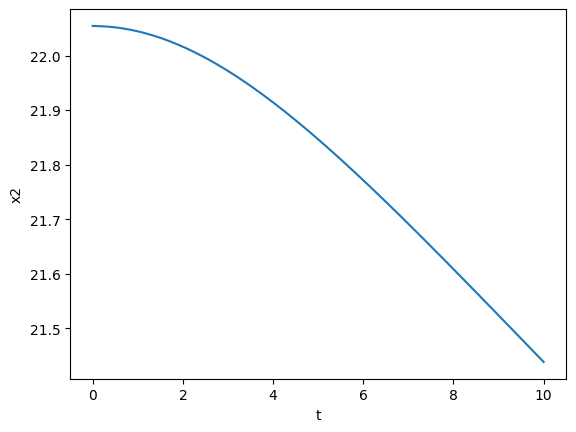

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

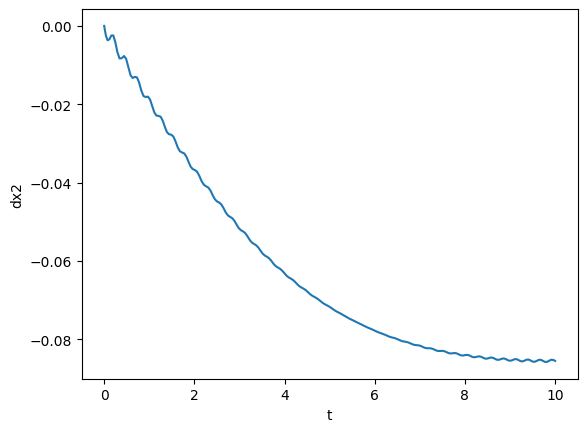

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

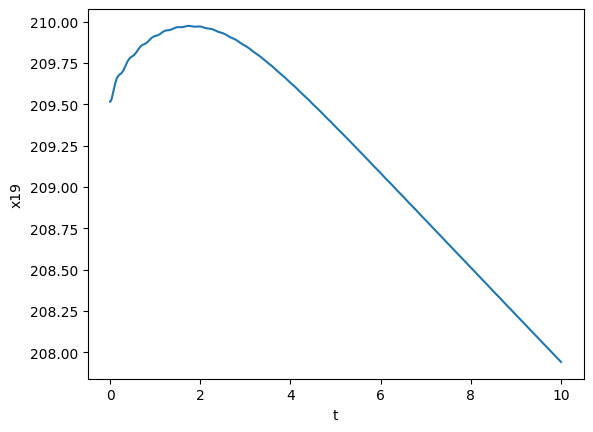

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

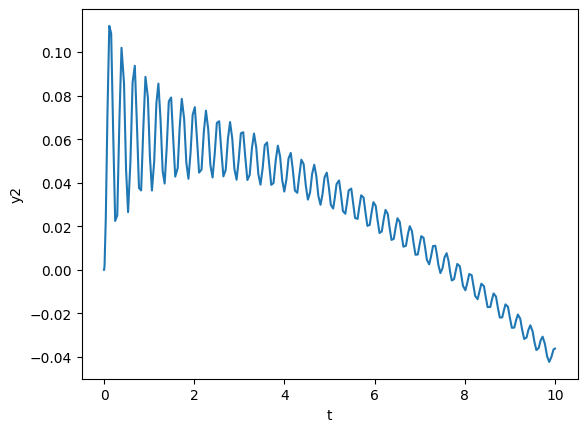

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

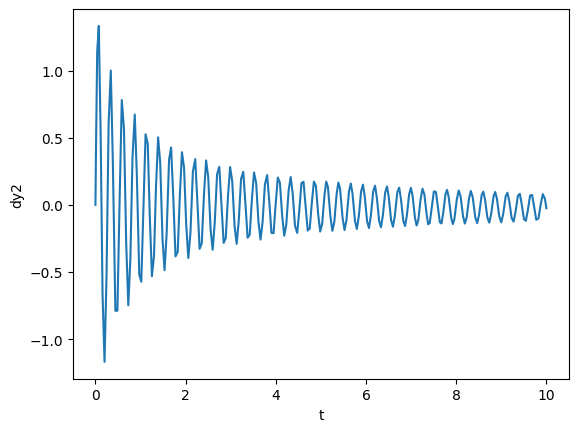

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

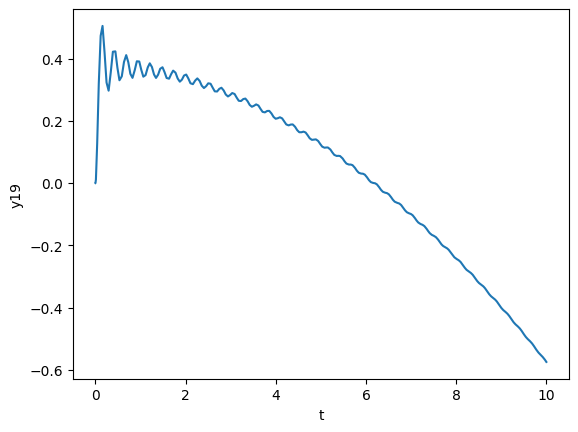

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

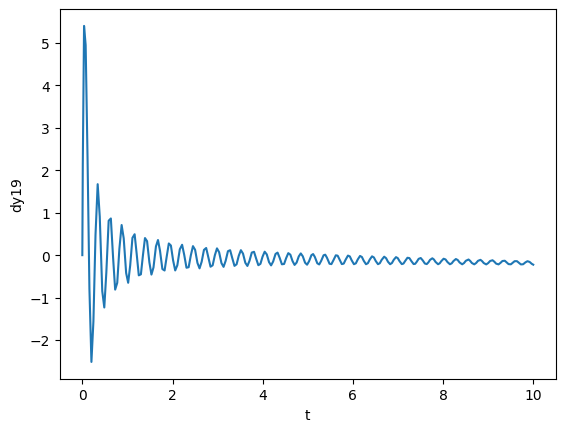

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

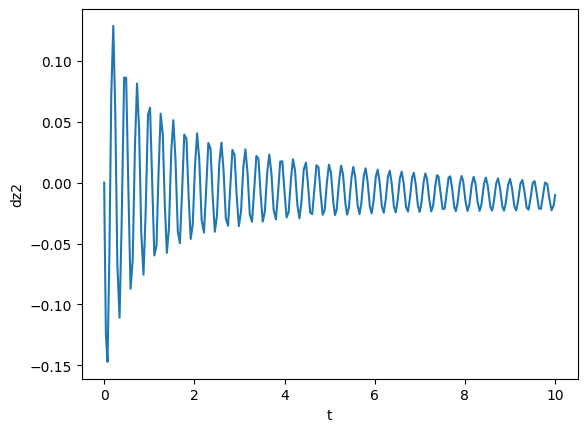

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

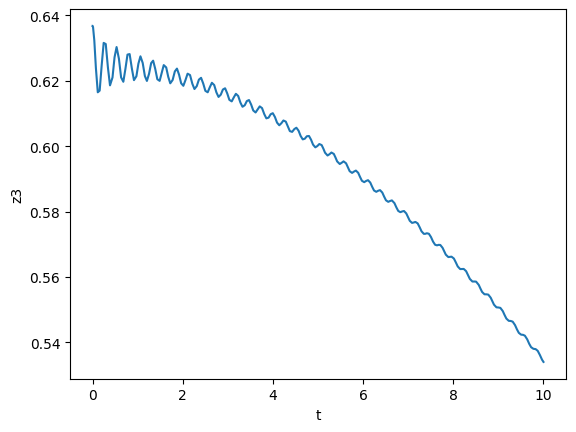

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

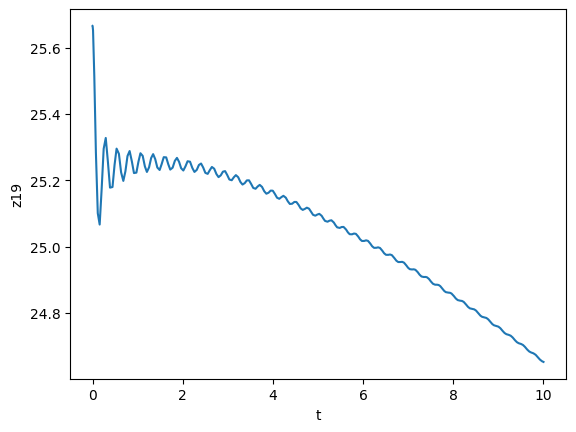

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

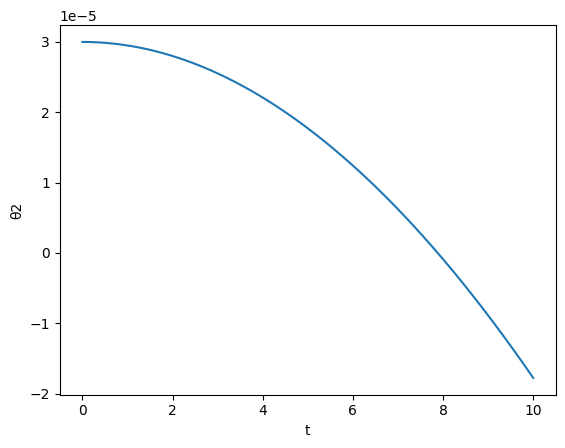

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

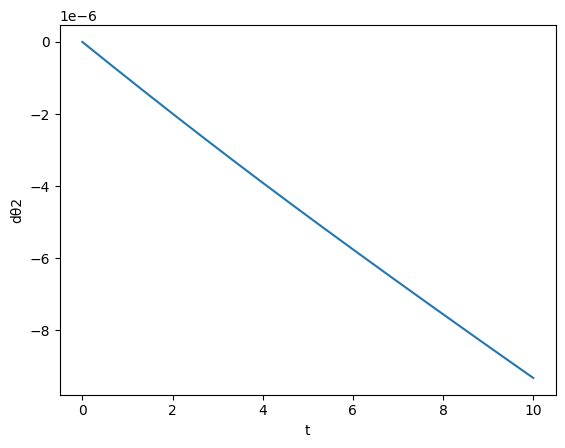

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

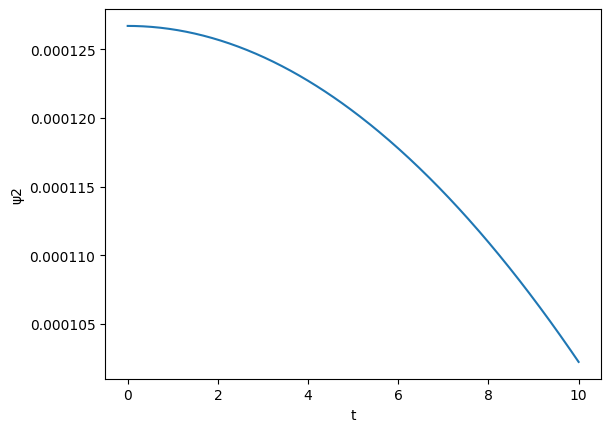

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

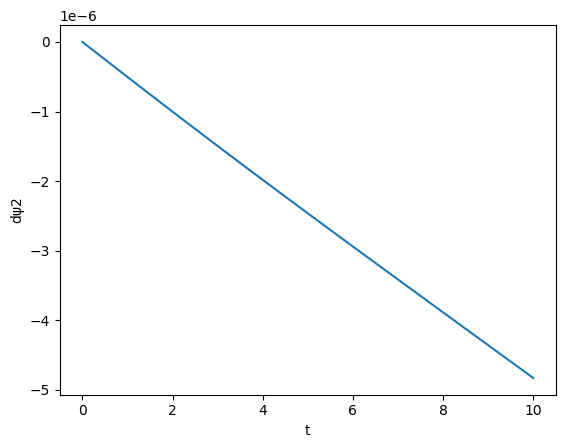

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

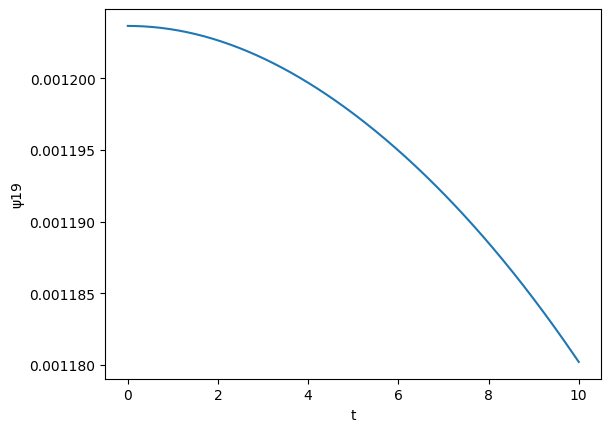

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()